# Category LPP by Recall

> Compare LPP amplitudes for recalled vs unrecalled items within a category.

This analysis splits items by recall outcome within a category, comparing LPP amplitudes at each study position for items that were subsequently recalled versus those that were not. A subsequent memory effect appears when recalled items show higher LPP than unrecalled items.

This notebook is parameterized for use with [papermill](https://papermill.readthedocs.io/).

| Parameter | Description |
|-----------|-------------|
| `data_path` | Path to HDF5 dataset file |
| `figure_dir` | Directory for saving figures |
| `figure_str` | Filename for saved figure (empty string to skip saving) |
| `ylim` | Y-axis limits as tuple, or `None` for auto |
| `trial_query` | Query string for trial selection |
| `category_field` | Key providing item categories per study position |
| `category_value` | Category to split by recall outcome |
| `lpp_field` | Key providing LPP values per study position |
| `exclude_ci` | If True, skip confidence intervals |
| `contrast_name` | Legend title |
| `labels` | Legend labels per recall outcome |

: Notebook parameters {#tbl-parameters}

In [1]:
#| include: false
from nbdev.showdoc import show_doc

In [2]:
#| code-summary: Imports and setup
import os
import warnings

import jax.numpy as jnp
import matplotlib.pyplot as plt

from jaxcmr.analyses.cat_lpp_by_recall import plot_cat_lpp_by_recall, expand_categories_by_recall
from jaxcmr.analyses.cat_lpp_spc import cat_lpp_spc
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data

warnings.filterwarnings("ignore")


def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()

In [3]:
#| code-summary: Parameters for this analysis

run_tag = "Category LPP by Recall"
data_path = "data/TalmiEEG.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
trial_query = "data['subject'] > 0"
category_field = "condition"
category_value = 1
lpp_field = "EarlyLPP"
labels = ["Recalled", "Unrecalled"]
contrast_name = "Negative Items"
exclude_ci = False

In [4]:
#| code-summary: Load data and generate trial mask
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)

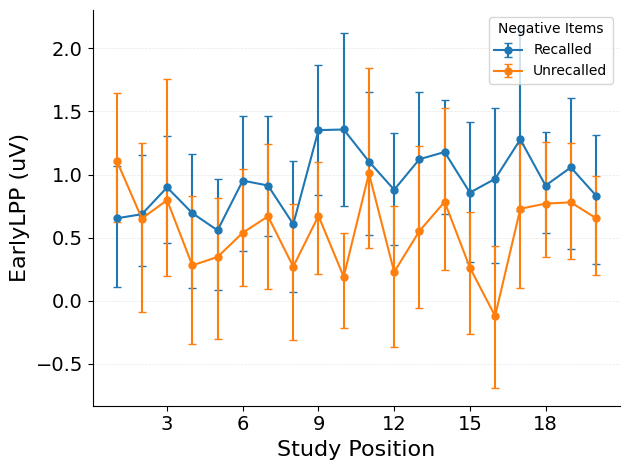

In [5]:
#| code-summary: Plot LPP by recall outcome for the selected category
#| label: fig-cat-lpp-by-recall
#| fig-cap: "LPP by recall outcome for the selected category."
plot_cat_lpp_by_recall(data, trial_mask, category_field=category_field, category_value=category_value, lpp_field=lpp_field, labels=labels, contrast_name=contrast_name, exclude_ci=exclude_ci)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)

---

## Reference

In [6]:
#| echo: false
show_doc(plot_cat_lpp_by_recall)

---

### plot_cat_lpp_by_recall

>      plot_cat_lpp_by_recall (datasets:Union[Sequence[jaxcmr.typing.RecallDatas
>                              et],jaxcmr.typing.RecallDataset], trial_masks:Uni
>                              on[Sequence[jaxtyping.Bool[Array,'trial_count']],
>                              jaxtyping.Bool[Array,'trial_count']],
>                              category_field:str,
>                              category_value:Union[int,Sequence[int]],
>                              lpp_field:str='LateLPP', exclude_ci=False,
>                              color_cycle:Optional[list[str]]=None,
>                              labels:Optional[Sequence[str]]=None,
>                              contrast_name:Optional[str]=None,
>                              axis:Optional[matplotlib.axes._axes.Axes]=None,
>                              confidence_level:float=0.95)

*Plot recall-split LPP curves for a category.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| datasets | Union |  | One or more datasets to plot. |
| trial_masks | Union |  | Boolean mask(s) selecting trials. |
| category_field | str |  | Key providing item categories per study position. |
| category_value | Union |  | Category to split by recall outcome. |
| lpp_field | str | LateLPP | Key providing LPP values per study position. |
| exclude_ci | bool | False | If ``True``, skip confidence intervals. |
| color_cycle | Optional | None | Colors for each curve. |
| labels | Optional | None | Legend labels. |
| contrast_name | Optional | None | Legend title. |
| axis | Optional | None | Existing Axes to plot on. |
| confidence_level | float | 0.95 | Confidence level for error bounds. |
| **Returns** | **Axes** |  | **Axes with the recall-split LPP plot.** |

In [7]:
#| echo: false
show_doc(expand_categories_by_recall)

---

### expand_categories_by_recall

>      expand_categories_by_recall (dataset:jaxcmr.typing.RecallDataset,
>                                   category_field:str)

*Category labels split by recall outcome.*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| dataset | RecallDataset | Recall dataset with study event metadata. |
| category_field | str | Key with per-item category labels. |
| **Returns** | **Integer[Array, 'trial_count study_positions']** | **Remapped category labels encoding recall outcome.** |